## Uploading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("file.csv")
df.head()

Saving file.csv to file.csv


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


## Validation

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
df.isnull().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [5]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [6]:
df['Purchased'].value_counts()

,count
Purchased,
0,257
1,143


The data is already clean and processed

## Feature-Target Splitting

In [32]:
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

## Train-Test Splitting

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
y_pred

array([ 0.36269954,  0.97356109, -0.00371156,  0.72662375, -0.04583675,
        0.12344117,  0.74760863,  0.18670667,  0.43364401,  0.442411  ,
        0.26374437,  0.59210291, -0.11441833, -0.2966913 ,  0.22914272,
        0.44555105,  0.58349136,  0.58255877,  0.26859416,  0.77860394,
       -0.22873144,  0.17402248,  0.39245141,  0.92282435, -0.33912735,
        0.49454662,  0.50583193,  0.26405523,  1.02790418, -0.33067122,
        0.44303272, -0.12349618,  0.62328509,  0.14427062,  0.568942  ,
        0.30602499,  0.27251136,  0.34031578, -0.11395204, -0.15747611,
        0.46025583, -0.05929809, -0.2251251 ,  0.37976722, -0.18676168,
        0.80633521,  0.0936893 ,  0.18701753,  0.49408033,  0.1452032 ,
        0.0676992 ,  0.7950499 ,  0.29803516,  0.07192727,  0.37821291,
       -0.08420017,  1.05827777,  0.25811743,  0.19970172,  0.20815784,
        0.35769433,  0.22991988,  0.80335059,  0.17809511,  0.05970937,
        0.36397442,  0.54811255,  0.90404693,  0.34047121,  0.41

## Evaluation

In [12]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.09929708810652677


In [13]:
x = model.predict([[30 , 100000]])
print(f"{x[0] * 100}%")

28.41075295457749%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Logisitc Regression

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [39]:
df = pd.read_csv("file.csv")
X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [41]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8875


In [43]:
x = model.predict([[30 , 12000]])
print(f"{x[0]}")

0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [44]:
x = model.predict([[18 , 1000000]])
print(f"{x[0]}")

1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


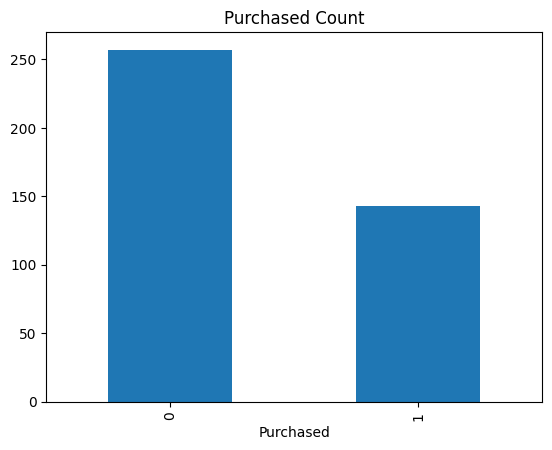

,count
Purchased,
0,257
1,143


In [47]:
import pandas as pd

pd.Series(y).value_counts().plot(kind='bar')
plt.title("Purchased Count")
plt.show()

df["Purchased"].value_counts()

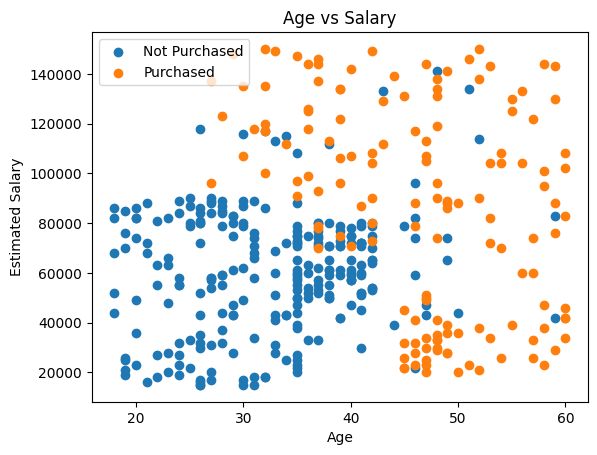

In [22]:
plt.scatter(X[y==0]['Age'], X[y==0]['EstimatedSalary'], label="Not Purchased")
plt.scatter(X[y==1]['Age'], X[y==1]['EstimatedSalary'], label="Purchased")

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Salary")
plt.legend()
plt.show()

Confusion Matrix

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[50  2]
 [ 7 21]]


|Actual	|Predicted No	|Predicted Yes|
|-------|-------------|-------------|
|No Purchase	|50|	2
|Purchase|	7	|21

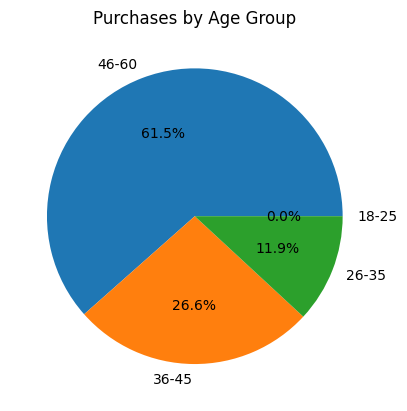

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[18,25,35,45,60],
                        labels=['18-25','26-35','36-45','46-60'])

purchased = df[df['Purchased'] == 1]
age_counts = purchased['AgeGroup'].value_counts()

plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title("Purchases by Age Group")
plt.show()